## **Best Model:** SVM MODEL (Linear_SVC)

We selected LinearSVC as our final model because it outperformed the random forest model on the relevant classes. Our primary objective was to classify restaurants into risk categories based on their respective grades. while our regression models had decent r2 scores, it was difficult for them to map out the grades into distinct risk categories. The LinearSVC model optimized directly for these decision boundaries.


In [2]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading in data: bringing the entire training and test sets
train_df = pd.read_parquet("../data/train_NYC_inspection.parquet")
test_df = pd.read_parquet("../data/test_NYC_inspection.parquet")

# Predictable grade values:
valid_grades = ['A', 'B', 'C', 'N','P','Z']

# Filter Training Data
train_df = train_df[train_df['GRADE'].isin(valid_grades)].copy()
X_train = train_df.drop(columns=['GRADE', 'SCORE']) # removing target variable as well as score 
# since it is used to determine grade
y_train = train_df['GRADE'] # target variable, we are predicting GRADE

# Same Filtering for Test Data:
test_df_clean = test_df[test_df['GRADE'].isin(valid_grades)].copy()
X_test = test_df_clean.drop(columns=['GRADE', 'SCORE'])
y_test = test_df_clean['GRADE']

# Print dimensions for datasets:
print(f"Training Shape: {train_df.shape}")
print(f"Testing Shape (Cleaned): {test_df_clean.shape}")

Training Shape: (68423, 10)
Testing Shape (Cleaned): (17053, 10)


In [3]:
# --- FINAL MODEL TRAINING AND EVALUATION ---

# Using best model: LinearSVC from previous hyperparameter tuning
# Using the best parameters determined (for LinearSVC): C=0.1, class_weight='balanced'
numeric_features = ['Latitude', 'Longitude', 'ZIPCODE']
categorical_features = ['CUISINE DESCRIPTION', 'BORO']

# Same preprocessing setups used in the
#  support_vector_machine.ipynb notebook:

# ---- PIPELINES ---- 
# Using pipelines to handle preprocessing more efficiently 

# Numeric pipeline:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # imputing missing values with median for numeric
    ('scaler', StandardScaler()) # standardizing numeric features
])

# Categorical pipeline:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # imputing missing values with most frequent for categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # one-hot encoding categorical features
])

# Combining both pipelines:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
])

# ---- FINAL MODEL PIPELINE ----
# Best Model: LinearSVC
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(C=0.1, dual=False, class_weight='balanced', random_state=42))
])

# FITTING on the FULL TRAINING SET:
print("Training Final Model (LinearSVC)...")
final_model.fit(X_train, y_train)

# Evaluate training performance:
print("\n--- TRAINING SET PERFORMANCE ---")
y_train_pred = final_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

# PREDICTION on the TEST SET:
y_pred = final_model.predict(X_test)

# Printing out our final evaluation metrics:
print("\n=== FINAL TEST SET RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training Final Model (LinearSVC)...

--- TRAINING SET PERFORMANCE ---
Training Accuracy: 0.5479

=== FINAL TEST SET RESULTS ===
Accuracy: 0.5501084853105026

Classification Report:
               precision    recall  f1-score   support

           A       0.68      0.80      0.74     10791
           B       0.19      0.04      0.07      2038
           C       0.18      0.15      0.16      1590
           N       0.31      0.13      0.18      1323
           P       0.01      0.04      0.02        80
           Z       0.15      0.22      0.18      1231

    accuracy                           0.55     17053
   macro avg       0.25      0.23      0.22     17053
weighted avg       0.51      0.55      0.52     17053



<Figure size 800x600 with 0 Axes>

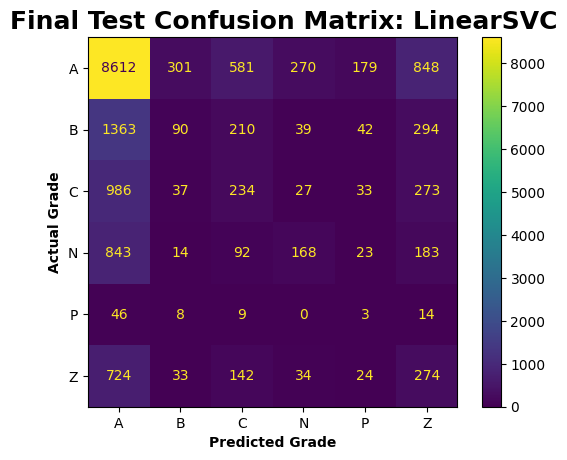

In [7]:
# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
# Display:
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot()
# Formatting:
plt.title('Final Test Confusion Matrix: LinearSVC',  weight='bold', fontsize=18, x = 0.53)
plt.xlabel('Predicted Grade',  weight='bold')
plt.ylabel('Actual Grade',  weight='bold')
plt.savefig("../output/figures/final_test_confusion_matrix_LineaSVC.png", dpi=300)
plt.show()


### **Final Evaluation:** 

Our model achieved a training accuracy of about 54.8% and a testing accuracy of about 55.0%. The scores indicate that the model is generalizing reasonably well to the unseen/test data and is not displaying any significant overfitting. As seen in the confusion matrix, the model performed best in identifying restaurants with grade A (low risk), which can be attributed to the imbalanced distribution of grades within the dataset (about 90% of restaurants received As). 